In [ ]:
pip install langchain-openai langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [ ]:
pip install trafilatura

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.3 MB/s eta 0:00:00


In [ ]:
import requests

In [ ]:
def normalize_to_ticker(company):
    url = "https://query1.finance.yahoo.com/v1/finance/search"
    params = {"q": company}

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    try:
        response = requests.get(url, params=params, headers=headers)
        data = response.json()

        quotes = data.get("quotes", [])

        for item in quotes:
            symbol = item.get("symbol")
            if symbol:
                return symbol

        return None

    except Exception as e:
        print("Error:", e)
        return None

In [ ]:
company_name = input("Enter company name: ")

ticker = normalize_to_ticker(company_name)

print("Ticker:", ticker)

Enter company name: apple
Ticker: AAPL


In [ ]:
import yfinance as yf
import pandas as pd

def fetch_stock_data(ticker, period="1d", interval="1m"):
    try:
        stock = yf.Ticker(ticker)

        # Historical data
        hist = stock.history(period=period, interval=interval)

        if hist.empty:
            return None

        # Reset index for easier handling
        hist.reset_index(inplace=True)

        # Keep only useful columns
        hist = hist[["Datetime", "Open", "High", "Low", "Close", "Volume"]]

        # Current price (latest close)
        current_price = hist["Close"].iloc[-1]

        return {
            "data": hist,
            "current_price": current_price
        }

    except Exception as e:
        print("Error fetching stock data:", e)
        return None

In [ ]:
result = fetch_stock_data(ticker)

if result:
    df = result["data"]
    price = result["current_price"]

    print("Current Price:", price)
    print(df)

Current Price: 300.2200012207031
                     Datetime        Open        High         Low       Close  \
0   2026-05-15 09:30:00-04:00  297.755005  298.179993  296.890015  296.989990   
1   2026-05-15 09:31:00-04:00  296.970001  298.265015  296.529999  298.179993   
2   2026-05-15 09:32:00-04:00  298.239990  298.540009  298.000000  298.170013   
3   2026-05-15 09:33:00-04:00  298.200012  298.200012  297.350006  297.549988   
4   2026-05-15 09:34:00-04:00  297.559998  297.589996  297.190796  297.420013   
..                        ...         ...         ...         ...         ...   
385 2026-05-15 15:55:00-04:00  300.230011  300.660004  300.230011  300.579987   
386 2026-05-15 15:56:00-04:00  300.570007  300.575012  300.350006  300.429901   
387 2026-05-15 15:57:00-04:00  300.420013  300.500000  300.339996  300.410004   
388 2026-05-15 15:58:00-04:00  300.412506  300.420013  300.140015  300.239990   
389 2026-05-15 15:59:00-04:00  300.244995  300.399994  300.100006  300.22000

In [ ]:
import matplotlib.pyplot as plt
import base64
from io import BytesIO

def plot_stock_prices(stock_data):

    # Extract Close prices
    data = stock_data['data']

    close_prices = data['Close']

    # Create histogram
    plt.figure(figsize=(40,8))

    plt.plot(df["Datetime"], df["Close"], marker='.')

    plt.title("Stock Price Distribution")
    plt.xlabel("Date")
    plt.ylabel("Closing price")

    # Save image to memory
    buffer = BytesIO()

    plt.savefig(buffer, format="png")

    # Show histogram
    plt.show()

    plt.close()

    # Convert image to base64
    buffer.seek(0)

    image_base64 = base64.b64encode(buffer.read()).decode("utf-8")

    return image_base64

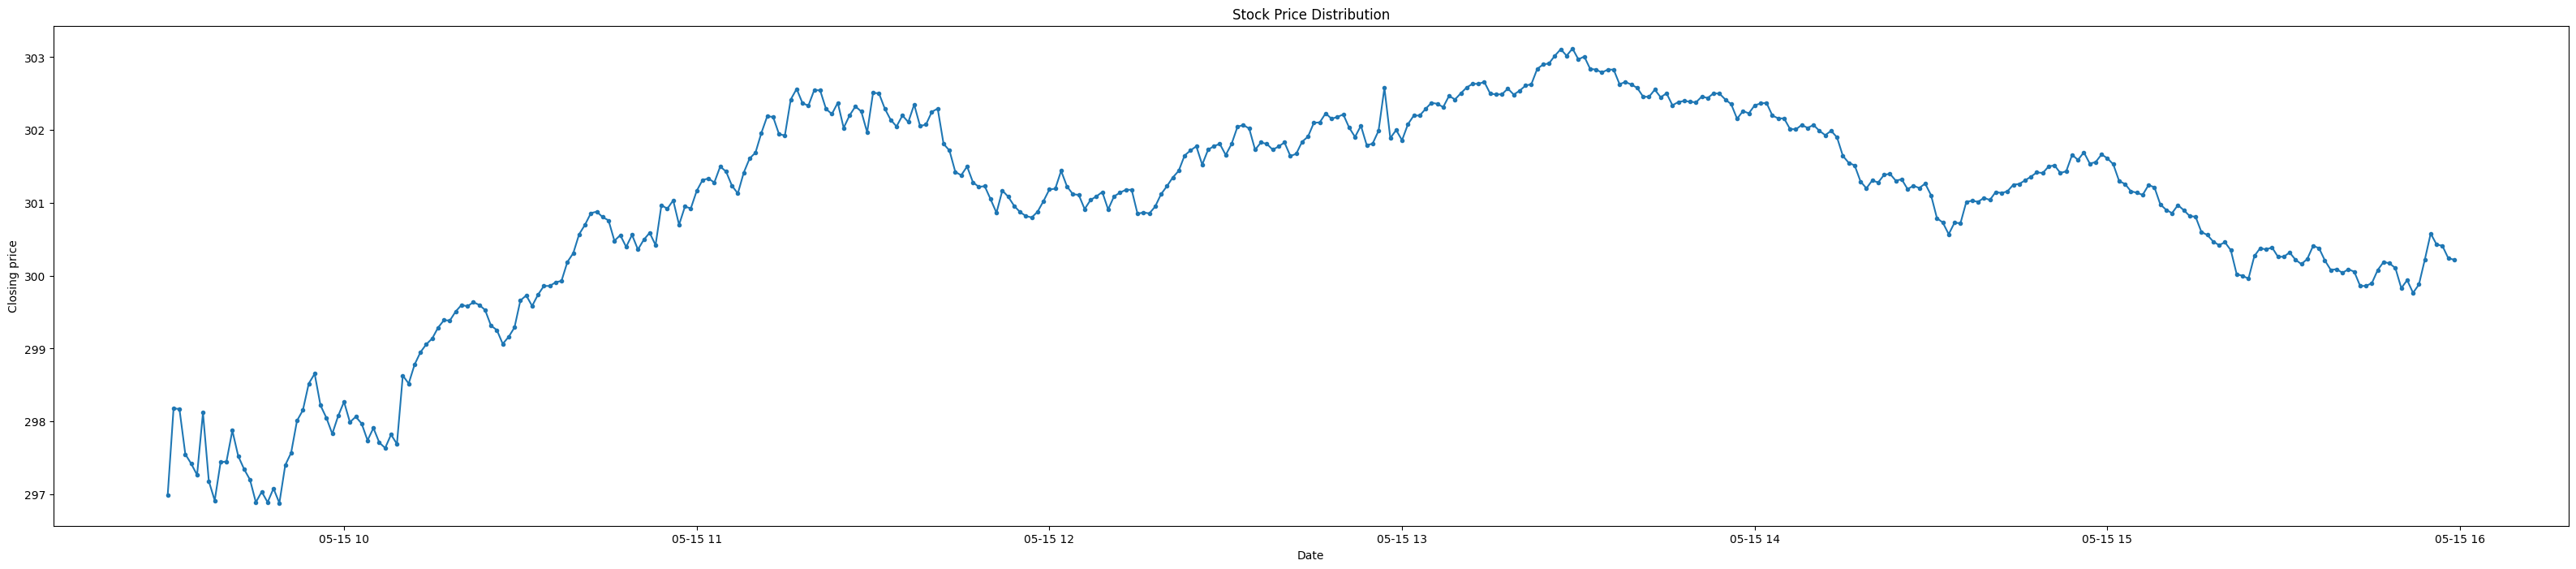

In [ ]:
stock_data = fetch_stock_data(ticker)

image_base64 = plot_stock_prices(stock_data)

In [ ]:
import requests

def get_company_news(company):
    url = "https://google.serper.dev/news"

    payload = {
        "q": f"{company} stock latest news",
        "num": 5
    }

    headers = {
        "X-API-KEY": "4396a1667a88f0584b06d1d57ba1348b2daa2739",
        "Content-Type": "application/json"
    }

    try:
        response = requests.post(url, json=payload, headers=headers)
        data = response.json()

        news_list = []

        for item in data.get("news", []):
            news_list.append({
                "title": item.get("title"),
                "link": item.get("link"),
                "snippet": item.get("snippet"),
                "date": item.get("date")
            })

        return news_list

    except Exception as e:
        print("Error:", e)
        return []


# Example usage
news = get_company_news(company_name)

for n in news:
    print(n)

{'title': "Apple Stock Is Gaining Today: What's Happening Behind The Scenes?", 'link': 'https://finance.yahoo.com/news/apple-stock-gaining-today-whats-181729752.html', 'snippet': 'Apple Inc (NASDAQ:AAPL) shares are moving up on Wednesday. The company plans to update its iPhone software, including a fully customizable...', 'date': '2 days ago'}
{'title': 'Apple (AAPL) Stock Quotes, Company News And Chart Analysis', 'link': 'https://www.investors.com/news/technology/apple-stock-quotes-company-news-and-chart-analysis/', 'snippet': "This Apple Stock page get's you the latest iPhone, Mac and other Apple product news, plus stock quotes and chart analysis.", 'date': '2 days ago'}
{'title': "Apple's shares hit an all-time high and this is what it means", 'link': 'https://www.phonearena.com/news/why-apples-shares-hit-an-all-time-high_id180404', 'snippet': "Apple's stock price had been dormant for a while, but now the stock is red-hot as it set an all-time record close on Friday, finally getting

In [ ]:
import requests
import trafilatura

def extract_article(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept-Language": "en-US,en;q=0.9"
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code != 200:
            return None

        html = response.text

        text = trafilatura.extract(html)

        return text

    except Exception as e:
        print("Error:", e)
        return None

In [ ]:
news = get_company_news(company_name)


In [ ]:
for n in news:
    content = extract_article(n["link"])

    print("\n====================")
    print("Title:", n["title"])
    print("Content:", content if content else "No content")


Title: Apple Stock Is Gaining Today: What's Happening Behind The Scenes?
Content: Apple Inc (NASDAQ:AAPL) shares are moving up on Wednesday. The company plans to update its iPhone software, including a fully customizable Camera app, a rebuilt Siri and broader user interface changes across core apps. Here’s what you should know.
-
Apple stock is challenging resistance. Why are AAPL shares at highs?
Apple is redesigning its Camera app, letting users choose their own layout and controls, a shift that appeals to both everyday users and professionals, Bloomberg reported.
Key Features
Apple is planning to let users pick which controls appear in the Camera interface and where they sit. This includes flash, exposure, timer, resolution, depth‑of‑field tools and new grid and level options. Users can switch to an advanced mode or build their own control set from a widget tray. The app will also include a new Siri mode that taps into Apple's visual intelligence for tasks like identifying objects 

In [ ]:
def is_hot_news(text):
    if not text:
        return False

    keywords = [
        "earnings", "revenue", "profit", "loss",
        "forecast", "guidance",
        "upgrade", "downgrade", "rating",
        "buy", "sell", "target price",
        "ceo", "resign", "appoint",
        "merger", "acquisition",
        "lawsuit", "regulation",
        "growth", "decline", "surge", "drop"
    ]

    text = text.lower()
    count = 0

    for word in keywords:
        if word in text:
            count += 1

    return count >= 2

In [ ]:
hot_news = []

for n in news:
    content = extract_article(n["link"])

    if content and is_hot_news(content):
        hot_news.append({
            "title": n["title"],
            "content": content
        })

In [ ]:
hot_news

[{'title': "Apple Stock Is Gaining Today: What's Happening Behind The Scenes?",
  'content': 'Apple Inc (NASDAQ:AAPL) shares are moving up on Wednesday. The company plans to update its iPhone software, including a fully customizable Camera app, a rebuilt Siri and broader user interface changes across core apps. Here’s what you should know.\n-\nApple stock is challenging resistance. Why are AAPL shares at highs?\nApple is redesigning its Camera app, letting users choose their own layout and controls, a shift that appeals to both everyday users and professionals, Bloomberg reported.\nKey Features\nApple is planning to let users pick which controls appear in the Camera interface and where they sit. This includes flash, exposure, timer, resolution, depth‑of‑field tools and new grid and level options. Users can switch to an advanced mode or build their own control set from a widget tray. The app will also include a new Siri mode that taps into Apple\'s visual intelligence for tasks like ide

In [ ]:
for h in hot_news:
    print("\n🔥 HOT NEWS")
    print("Title:", h["title"])


🔥 HOT NEWS
Title: Apple Stock Is Gaining Today: What's Happening Behind The Scenes?

🔥 HOT NEWS
Title: Apple (AAPL) Stock Quotes, Company News And Chart Analysis

🔥 HOT NEWS
Title: Apple Inc. $AAPL Stock Position Boosted by Sterling Investment Counsel LLC

🔥 HOT NEWS
Title: Is Apple Stock Back in Style?

🔥 HOT NEWS
Title: Apple stock (US0378331005): Shares near record levels after latest rally

🔥 HOT NEWS
Title: Apple's stock gains as company execs cite iPhone, Mac demand in boosting guidance


In [ ]:
def combine_hot_news(hot_news):
    combined_text = ""

    for article in hot_news:
        if article["content"]:
            combined_text += article["content"] + "\n\n"

    return combined_text

In [ ]:
news1 = combine_hot_news(hot_news)
print(news1)

Apple Inc (NASDAQ:AAPL) shares are moving up on Wednesday. The company plans to update its iPhone software, including a fully customizable Camera app, a rebuilt Siri and broader user interface changes across core apps. Here’s what you should know.
-
Apple stock is challenging resistance. Why are AAPL shares at highs?
Apple is redesigning its Camera app, letting users choose their own layout and controls, a shift that appeals to both everyday users and professionals, Bloomberg reported.
Key Features
Apple is planning to let users pick which controls appear in the Camera interface and where they sit. This includes flash, exposure, timer, resolution, depth‑of‑field tools and new grid and level options. Users can switch to an advanced mode or build their own control set from a widget tray. The app will also include a new Siri mode that taps into Apple's visual intelligence for tasks like identifying objects or translating text.
Siri will shift from a traditional voice assistant to a conver

In [ ]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

os.environ["OPENAI_API_KEY"] = ""  # add your key

llm = ChatOpenAI(
    temperature=0,
    model="gpt-5-nano"
)

def analyze_combined_news(combined_text):
    prompt = f"""
    Analyze the following combined stock news:

    1. Give a clear summary
    2. Classify overall sentiment as Positive, Negative, or Neutral
    3. Mention main reasons affecting the stock

    News:
    {combined_text}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return response.content

In [ ]:
combined_text = combine_hot_news(hot_news)

result = analyze_combined_news(combined_text)

print(result)

1) Clear summary
- Apple (AAPL) stock is rising as investors digest upcoming iPhone software updates (including a customizable Camera app, a more capable Siri, and broader iOS 27 UI changes) alongside strong earnings momentum, buyback activity, and upbeat analyst revisions. The stock is trading near/at record highs with bullish technicals, though overbought signals and several risk factors are noted.

2) Overall sentiment
- Positive

3) Main reasons affecting the stock
- Positive catalysts
  - Product/software updates: Customizable Camera controls, new Siri capabilities, and iOS 27 UI refresh, plus deeper AI features and cross-app actions, potentially boosting user engagement and ecosystem stickiness.
  - Earnings and guidance: Quarterly results beat expectations (EPS $2.01 on $111.18B revenue) with strong services/mac contributions and upbeat revenue guidance for the next quarter.
  - Capital returns: Announced or continued buybacks and dividend increase, supporting shareholder value.

In [ ]:
def get_sentiment(text):
    prompt = f"""
    Analyze the sentiment of this stock news.

    Return ONLY one word:
    Positive or Negative or Neutral

    News:
    {text}
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content.strip()

In [ ]:
from langchain_core.messages import HumanMessage

def generate_final_output(
    company,
    price,
    summary,
    sentiment,
    image_base64
):

    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": f"""
You are a stock advisor for beginners.

Analyze the histogram image carefully.

Generate output EXACTLY in this format:

company: {company}

Current Price: ₹{price}

News Sentiment: {sentiment}

Analysis:
[Explain using line chart + news. make sure it is in points]

Recommendation1:
[I want to you suggest whether it is safe to invest or not? ]

Reason1:
[here i want you to give the reason for you recommendation. make sure the it is in  points]

Recommendation2:
[if the recommendation1 says safe to invest recomend me to invest short-term or long-term?]

Reason2:
[here i want you to give the reason for you recommendation. make sure the it is in  points]


Risk:
- point 1
- point 2
"""
            },

            {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{image_base64}"
            }
            }
        ]
    )

    response = llm.invoke([message])

    return response.content

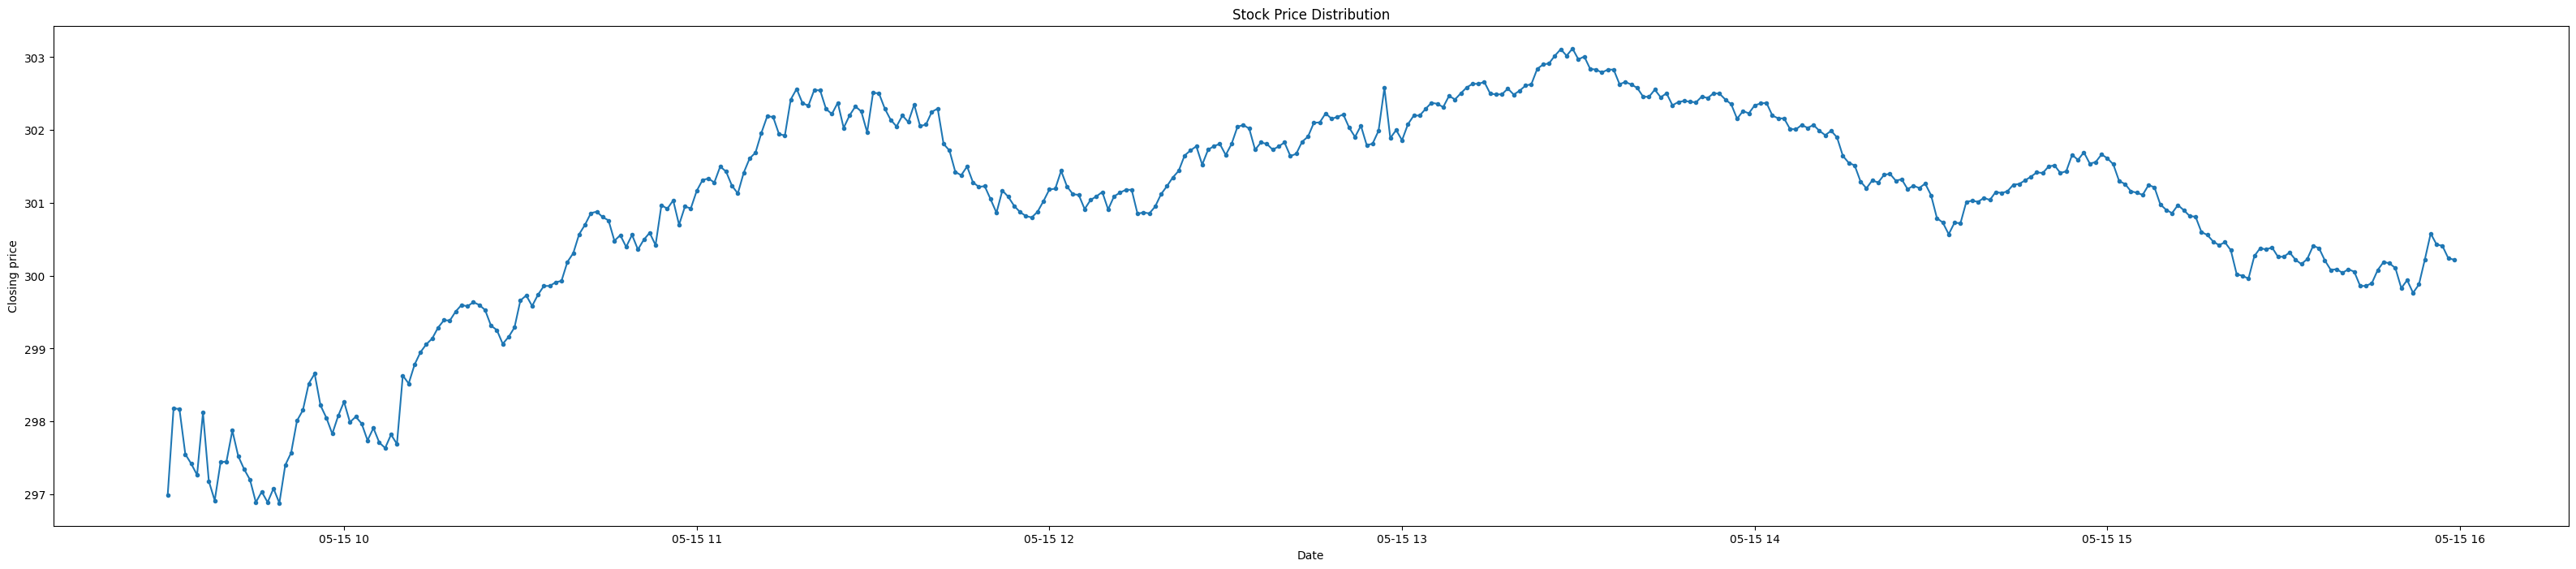

company: apple

Current Price: ₹300.2200012207031

News Sentiment: Positive

Analysis:
- The line chart shows price rising from around ₹297 to a peak near ₹303 around mid-session, followed by a mild pullback and consolidation around ₹300 by the end.
- The price has remained within a narrow band, indicating balanced supply-demand and controlled volatility.
- The current price of ₹300.22 sits near the middle of the recent range, suggesting a potential support zone around ₹300.
- The accompanying news sentiment is Positive, supporting a bullish tilt in investors’ minds.
- Overall, the chart pattern plus positive news implies a cautiously bullish outlook for longer-term investors.

Recommendation1:
Safe to invest

Reason1:
- Upward drift from the low ₹297 to the high near ₹303 indicates constructive momentum.
- Price stabilizing around ₹300 suggests a potential support level and reduced downside risk in the near term.
- Positive news sentiment reinforces the probability of continued earnin

In [ ]:
# Fetch stock data
stock_data = fetch_stock_data(ticker)

# Generate histogram image
image_base64 = plot_stock_prices(stock_data)

# Summary (your existing function)
summary = analyze_combined_news(combined_text)

# Sentiment
sentiment = get_sentiment(combined_text)

# Generate final AI output
result = generate_final_output(
    company=company_name,
    price=price,
    summary=summary,
    sentiment=sentiment,
    image_base64=image_base64
)

print(result)